In [1]:
import os
import glob
import gc

import numpy as np
from sklearn import linear_model
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc

import celltypist
from celltypist import models
from celltypist.classifier import AnnotationResult

%matplotlib inline

In [2]:
## Read in Scz Atlas ##

scz_adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated.h5ad')

In [3]:
## Load Braun & HNOCA scANVI Predictions ##

pred_braun = pd.read_csv("/mnt/sdb/scz_meta_analysis_processed/anndata_objs/adata_pred_celltype_from_braun.csv", index_col=0)
pred_hnoca = pd.read_csv("/mnt/sdb/scz_meta_analysis_processed/anndata_objs/adata_pred_celltype_from_hnoca.csv", index_col=0)

## Apply HNOCA & Braun Predictions ##
scz_adata.obs['Braun_SCANVI_Pred'] = pred_braun
scz_adata.obs['HNOCA_SCANVI_Pred'] = pred_hnoca

In [4]:
# Live or Fixed - all are live except for some from Sebastian 

# generalize sebastians procedure column to the rest
scz_adata.obs['procedure'].fillna('live', inplace=True)
scz_adata.obs.rename({'procedure':'Live_Or_Fixed'}, inplace=True, axis=1)

# Clinical Notes from Notaras Needs to be Integrated #

scz_adata.obs['Diagnosis'] = scz_adata.obs['Diagnosis'].astype('str')
scz_adata.obs['Clinical Notes'] = scz_adata.obs['Clinical Notes'].astype('str')
scz_adata.obs.loc[scz_adata.obs['Diagnosis'].isnull(), 'Diagnosis'] = scz_adata.obs['Clinical Notes']
del scz_adata.obs['Clinical Notes']

# Regional Differentiation # - dorsal vs ventral telecephalon

# cell_type from fernando is a organoid differentiation and should be merged with Differentiation from Walsh
# most datasets missing Differentiation but all are Cortical except parts of Fernando and Walsh

scz_adata.obs['cell_type'] = scz_adata.obs['cell_type'].astype('str')
scz_adata.obs['Differentiation'] = scz_adata.obs['Differentiation'].astype('str')
scz_adata.obs.loc[scz_adata.obs['Differentiation'] == 'nan', 'Differentiation'] = scz_adata.obs['cell_type']
scz_adata.obs['Differentiation'] = scz_adata.obs['Differentiation'].str.replace('hiPSC-derived-hCS', 'Cortical')
scz_adata.obs['Differentiation'] = scz_adata.obs['Differentiation'].str.replace('hiPSC-derived-hSS', 'Ventral')
scz_adata.obs['Differentiation'] = scz_adata.obs['Differentiation'].str.replace('Cortical Organoid', 'Cortical')
scz_adata.obs.loc[scz_adata.obs['Differentiation'] == 'nan', 'Differentiation'] = 'Cortical' # impute remaining as cortical
del scz_adata.obs['cell_type']

# Homogenize Reprogramming Method #

# "Method of reprogramming" is Khan & "Derived by" is Shin #

scz_adata.obs['Method of reprogramming'] = scz_adata.obs['Method of reprogramming'].astype('str')
scz_adata.obs['Derived by'] = scz_adata.obs['Derived by'].astype('str')
scz_adata.obs.loc[scz_adata.obs['Method of reprogramming'].isnull(), 'Method of reprogramming'] = scz_adata.obs['Derived by'].astype('str')
scz_adata.obs.rename({'Method of reprogramming':'Reprogramming_Method'}, axis=1, inplace=True)
scz_adata.obs['Reprogramming_Method'] = scz_adata.obs['Reprogramming_Method'].str.replace('Episomal, Y4 mixture', 'Episomal')
del scz_adata.obs['Derived by']

# Homonogenize Ancestry/Ethncity from Notaras, Shin, Fernando

# Fernando uses European and Non European only. Convert to Caucasian.
# Notaras donors are all is all White (Caucasian)
# Shin donors are a mixture of Caucasian/Japanese/Unknown/Ad-mixed American

scz_adata.obs['Ethnicity'] = scz_adata.obs['Ethnicity'].astype('str')
scz_adata.obs.loc[((scz_adata.obs['Ethnicity'].isnull()) | (scz_adata.obs['Ethnicity'] == 'nan')), 'Ethnicity'] = scz_adata.obs['Ancestry']
scz_adata.obs['Ethnicity'] = scz_adata.obs['Ethnicity'].str.replace('European', 'Caucasian')
scz_adata.obs['Ethnicity'] = scz_adata.obs['Ethnicity'].str.replace('White', 'Caucasian')
del scz_adata.obs['Ancestry']
scz_adata.obs.rename({'Ethnicity':'Ancestry'}, inplace=True, axis=1)

# Homonogenize Age of Onset (First Break) #

# Age of Onset - Notaras
# Onset - Sawada
# Age of onset (y) - Fernando

# rework 20s as 20 as closest estimate and <8 to 8

scz_adata.obs['Age of Onset'] = scz_adata.obs['Age of Onset'].astype('str')
scz_adata.obs.loc[scz_adata.obs['Age of Onset'] == 'nan', 'Age of Onset'] = scz_adata.obs['Onset']
scz_adata.obs.loc[scz_adata.obs['Age of Onset'].isnull(), 'Age of Onset'] = scz_adata.obs['Age of onset (y)']
scz_adata.obs['Age of Onset'] = scz_adata.obs['Age of Onset'].str.replace('<','').str.replace('s', '') 
scz_adata.obs['Age of Onset'] = scz_adata.obs['Age of Onset'].replace('Unknown', np.nan)
scz_adata.obs['Age of Onset'] = scz_adata.obs['Age of Onset'].replace('N/A', np.nan)
scz_adata.obs['Age of Onset'] = scz_adata.obs['Age of Onset'].astype('float')
del scz_adata.obs['Age of onset (y)']
del scz_adata.obs['Onset']

# Homogenize Cell Type of Origin

# Parental Cells for iPSC reprogramming substrate - Sawada
# Cell Type of Origin  reprogramming substrate - Shin 

scz_adata.obs['Parental Cells for iPSC'] = scz_adata.obs['Parental Cells for iPSC'].astype('str')
scz_adata.obs.loc[(scz_adata.obs['Parental Cells for iPSC'] == 'nan'), 'Parental Cells for iPSC'] = scz_adata.obs['Cell Type of Origin']
scz_adata.obs['Parental Cells for iPSC'].replace('Unknown', np.nan, inplace=True)
del scz_adata.obs['Cell Type of Origin']

# Homogenize Imputed Sex 

# Notaras had Imputed_Male and Imputed_Female and Male.
scz_adata.obs['Imputed_Sex'] = scz_adata.obs['Imputed_Sex'].str.contains('Imputed', na=False).map({True: 'Imputed', False: 'Not'})

# Protocol 
scz_adata.obs['Protocol'] = scz_adata.obs['Protocol'].astype('str')
fernando_ventral_bool = ((scz_adata.obs['Differentiation'] == 'Ventral') & (scz_adata.obs['Manuscript'] == 'Fernando')) 
scz_adata.obs.loc[fernando_ventral_bool, 'Protocol'] = 'Pasca (Sloan) Ventral'

In [5]:
# Define Useful Cell Types #

scz_adata.obs['CellType'] = scz_adata.obs['subclass_annotations_markers'].astype('str')

scz_adata.obs.loc[scz_adata.obs['subtype_cluster_annotations_markers'].str.contains('IPC'), 'CellType'] = scz_adata.obs['subtype_cluster_annotations_markers']
scz_adata.obs.loc[scz_adata.obs['subtype_cluster_annotations_markers'].str.contains('OPC'), 'CellType'] = scz_adata.obs['subtype_cluster_annotations_markers']
scz_adata.obs.loc[scz_adata.obs['subtype_cluster_annotations_markers'].str.contains('Oligodendrocyte'), 'CellType'] = scz_adata.obs['subtype_cluster_annotations_markers']
scz_adata.obs.loc[scz_adata.obs['subtype_cluster_annotations_markers'].str.contains('Astrocyte'), 'CellType'] = scz_adata.obs['subtype_cluster_annotations_markers']

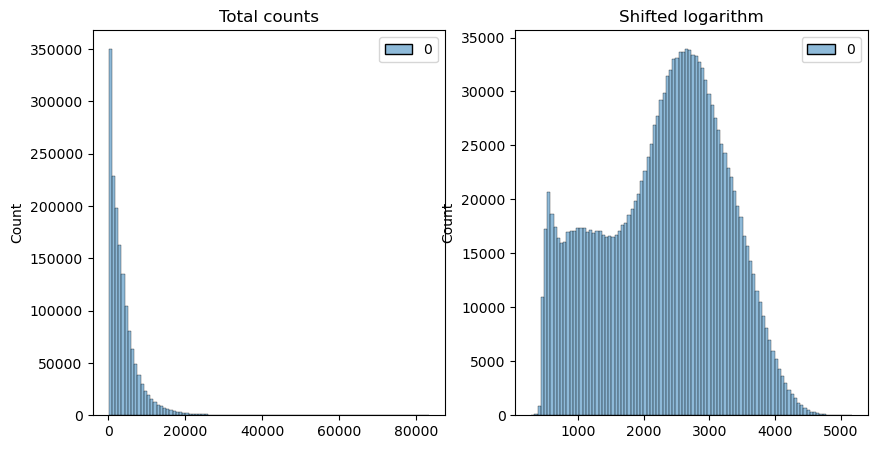

In [6]:
## Log Normalization ##

# normalize 
scales_counts = sc.pp.normalize_total(scz_adata, layer='raw_counts', target_sum=10000, inplace=False)

# log1p transform
scz_adata.layers["log1p_norm_10000"] = sc.pp.log1p(scales_counts["X"], copy=True)

# set X as log1p normed counts
scz_adata.X = scz_adata.layers["log1p_norm_10000"]

# recover memory
del scales_counts
gc.collect()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(scz_adata.layers["raw_counts"].sum(1), bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(scz_adata.layers["log1p_norm_10000"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

In [7]:
# Load your model (or pretrained model)

# hnoca annotations #
hnoca_tissue_model = models.Model.load('/home/deepak/datasets/reference_atlas_models/hnoca_tissue_model.pkl')
hnoca_cell_type_model = models.Model.load('/home/deepak/datasets/reference_atlas_models/hnoca_cell_type_model.pkl')
hnoca_annot_level_2 = models.Model.load('/home/deepak/datasets/reference_atlas_models/hnoca_annot_level_2_model.pkl')

# braun annotations #
braun_model = models.Model.load('/home/deepak/datasets/reference_atlas_models/Braun_Linarsson_Developing_Human_Brain.pkl')
braun_subregion_model = models.Model.load('/home/deepak/datasets/reference_atlas_models/braun_subregion_model.pkl')
braun_tissue_model = models.Model.load('/home/deepak/datasets/reference_atlas_models/braun_tissue_model.pkl')
braun_cellclass_model = models.Model.load('/home/deepak/datasets/reference_atlas_models/braun_cellclass_model.pkl')
braun_subregion_cellclass_model = models.Model.load('/home/deepak/datasets/reference_atlas_models/braun_subregion_cellclass_model.pkl')

In [8]:
## Annotate w/ Braun ##

org_braun_predictions = celltypist.annotate(scz_adata, model = braun_model, majority_voting = False)

org_braun_subregion_model_predictions = celltypist.annotate(scz_adata, model = braun_subregion_model, majority_voting = False)

org_braun_tissue_model_predictions = celltypist.annotate(scz_adata, model = braun_tissue_model, majority_voting = False)

org_braun_cellclass_model_predictions = celltypist.annotate(scz_adata, model = braun_cellclass_model, majority_voting = False)

org_braun_subregion_cellclass_model_predictions = celltypist.annotate(scz_adata, model = braun_subregion_cellclass_model, 
                                                                      majority_voting = False)

## Annotate w/ HNOCA Atlas ##

org_hnoca_tissue_predictions = celltypist.annotate(scz_adata, model = hnoca_tissue_model, majority_voting = False)

org_hnoca_cell_type_predictions = celltypist.annotate(scz_adata, model = hnoca_cell_type_model, majority_voting = False)

org_hnoca_annot_level_2_predictions = celltypist.annotate(scz_adata, model = hnoca_annot_level_2, majority_voting = False)

🔬 Input data has 1574165 cells and 19264 genes
🔗 Matching reference genes in the model
🧬 851 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🔬 Input data has 1574165 cells and 19264 genes
🔗 Matching reference genes in the model
🧬 1702 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🔬 Input data has 1574165 cells and 19264 genes
🔗 Matching reference genes in the model
🧬 1702 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🔬 Input data has 1574165 cells and 19264 genes
🔗 Matching reference genes in the model
🧬 1702 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🔬 Input data has 1574165 cells and 19264 genes
🔗 Matching reference genes in the model
🧬 1702 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🔬 Input data has 1574165 cells and 19264 genes
🔗 Matching reference genes in

In [9]:
## Apply Annotations ##

scz_adata.obs['braun_overall_ct'] = org_braun_predictions.predicted_labels
scz_adata.obs['braun_subregion_ct'] = org_braun_subregion_model_predictions.predicted_labels
scz_adata.obs['braun_tissue_ct'] = org_braun_tissue_model_predictions.predicted_labels
scz_adata.obs['braun_cellclass_ct'] = org_braun_cellclass_model_predictions.predicted_labels
scz_adata.obs['braun_subregion_cellclass_ct'] = org_braun_subregion_cellclass_model_predictions.predicted_labels

scz_adata.obs['hnoca_tissue_ct'] = org_hnoca_tissue_predictions.predicted_labels
scz_adata.obs['hnoca_celltype_ct'] = org_hnoca_cell_type_predictions.predicted_labels
scz_adata.obs['hnoca_annot_level_2_ct'] = org_hnoca_annot_level_2_predictions.predicted_labels

... storing 'Diagnosis' as categorical
... storing 'Protocol' as categorical
... storing 'Differentiation' as categorical
... storing 'Ancestry' as categorical
... storing 'Reprogramming_Method' as categorical
... storing 'Parental Cells for iPSC' as categorical
... storing 'Imputed_Sex' as categorical
... storing 'Braun_SCANVI_Pred' as categorical
... storing 'HNOCA_SCANVI_Pred' as categorical
... storing 'CellType' as categorical


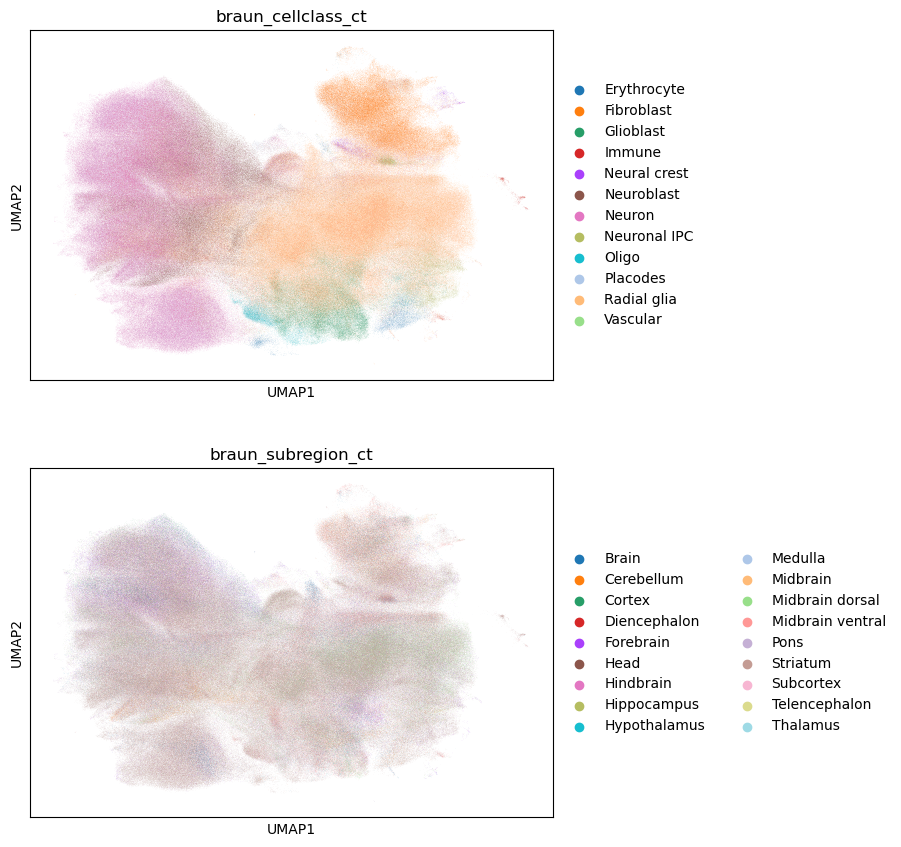

In [10]:
## Examine CellTypist Braun ##

sc.pl.umap(scz_adata, color=['braun_cellclass_ct', 'braun_subregion_ct'], ncols=1)

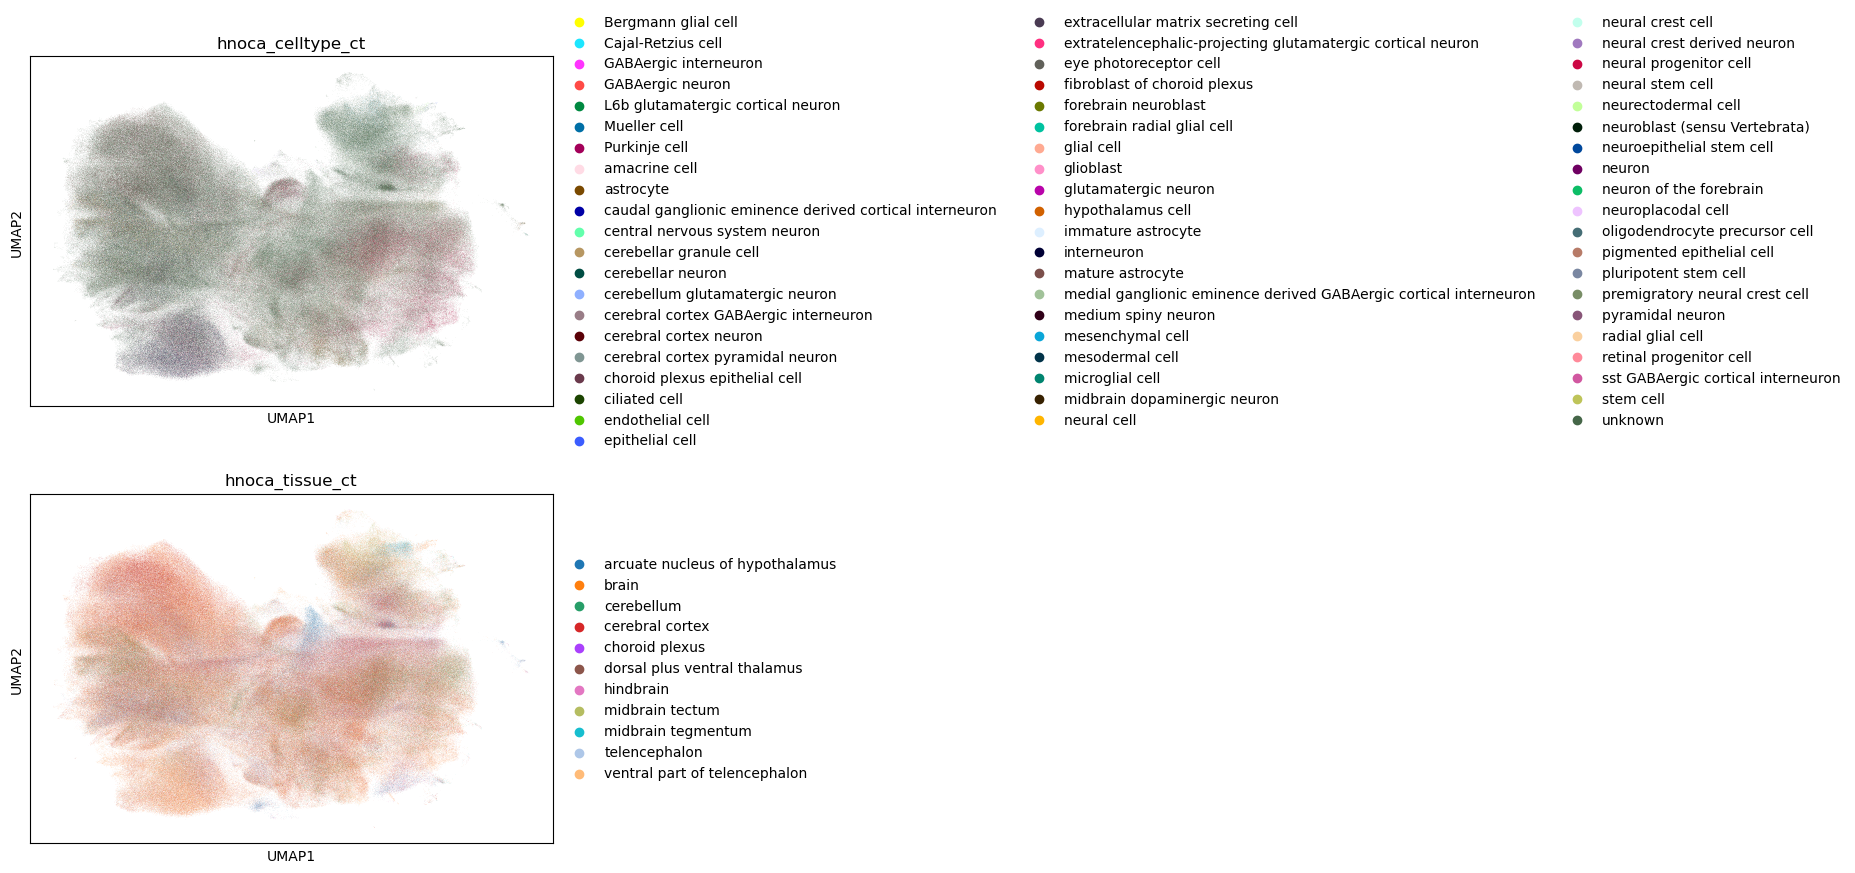

In [11]:
## Examine CellTypist HNOCA ##

sc.pl.umap(scz_adata, color=['hnoca_celltype_ct', 'hnoca_tissue_ct'], ncols=1)

In [12]:
## Create Generalized Genotype & Psychosis Cols ##

scz_adata.obs['Broad_Genotype'] = scz_adata.obs['Broad_Genotype'].str.replace(' deletion', 'del')
scz_adata.obs['Broad_Genotype'] = scz_adata.obs['Broad_Genotype'].str.replace('DS', 'del')
scz_adata.obs['Broad_Genotype'] = scz_adata.obs['Broad_Genotype'].str.replace(' ', '_')

scz_adata.obs['Psychosis'] = scz_adata.obs['Broad_Genotype'].apply(lambda x: 0 if x == 'Control' else 1)

In [13]:
## Create Pseudobulking Columns ##

scz_adata.obs['Sample Name'] = scz_adata.obs['Sample Name'].astype('str')
scz_adata.obs['Run_Donor'] = scz_adata.obs['Run'].astype('str') + '_' + scz_adata.obs['Donor'].astype('str')
scz_adata.obs['Run_Donor_Sample'] = scz_adata.obs['Run_Donor'] + '_' + scz_adata.obs['Sample Name']

In [14]:
## Write H5AD ##

scz_adata.write_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

... storing 'Sample Name' as categorical
... storing 'Run_Donor' as categorical
... storing 'Broad_Genotype' as categorical
... storing 'Run_Donor_Sample' as categorical


In [15]:
## Make Copy for SCANVI dreamlet Code Before Dropping Layers ##

scz_adata.obs['Broad_Genotype'] = scz_adata.obs['Broad_Genotype'].str.replace('.', '')

scanvi_scz_adata = scz_adata.copy()

In [16]:
## Make Dreamlet Ready Versions ##

## Save Fom Dreamlet - Disease Code ##

# drop doublets
scz_adata = scz_adata[~scz_adata.obs['pred_dbl']].copy()

# move raw counts to X
scz_adata.X = scz_adata.layers['raw_counts']

del scz_adata.layers
del scz_adata.uns
del scz_adata.obsm
del scz_adata.obsp

scz_adata.write_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_full_annotation_dreamlet.h5ad')

... storing 'Broad_Genotype' as categorical


In [17]:
## Make Dreamlet Ready Versions ##

## Save scANVI Matrix To Check Mixing ##

# drop doublets #
scanvi_scz_adata = scanvi_scz_adata[~scanvi_scz_adata.obs['pred_dbl']].copy()

# move scanvi
dreamlet_scanvi = sc.AnnData(X=scanvi_scz_adata.obsm['X_scVI'], 
                   obs=scanvi_scz_adata.obs, 
                   var=pd.DataFrame(index=[f"LATENT_DIM_{i}" for i in range(scanvi_scz_adata.obsm['X_scVI'].shape[1])]))

# write to file
dreamlet_scanvi.write_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_full_annotation_scanvi_loaded_dreamlet.h5ad')

... storing 'Broad_Genotype' as categorical
